# DEAP fold-1 native compact diagnostic

**TL;DR.** The available sqrt-JSD run is incomplete and does not demonstrate useful cross-subject learning: source training loss falls, while target performance remains around or below chance-balanced accuracy. Trial-pooled feature checks indicate that both candidate one-dimensional representations encode subject identity far more strongly than the four-quadrant emotion label. Fisher–Rao has not yet completed neural training; its unsupervised PC1 is therefore assessed here only with a linear sanity probe.

This notebook re-runs `reports/deap_fold1_diagnostic.py` from the cached fold-1 artifacts and renders the main diagnostic views.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().resolve()
if project_root.name == 'reports':
    project_root = project_root.parent
sys.path.insert(0, str(project_root / 'reports'))
from deap_fold1_diagnostic import run_analysis

result = run_analysis(write_outputs=True)
result['run_status'], result['sqrt_jsd_training']

({'sqrt_jsd': 'interrupted after epoch 190; no final result.json/checkpoint',
  'fisher_rao': 'pending; no neural training curve',
  'completed_target_curve_points': 19},
 {'epochs_completed': 190,
  'initial_train_loss': 1.3735918598790322,
  'final_train_loss': 0.9407065406922371,
  'relative_loss_reduction': 0.3151484307900003,
  'best_target_macro_f1': {'epoch': 180,
   'accuracy': 0.25,
   'balanced_accuracy': 0.23904428904428904,
   'macro_f1': 0.24150025601638503,
   'majority_accuracy': 0.325,
   'chance_balanced_accuracy': 0.25},
  'best_target_balanced_accuracy': {'epoch': 80,
   'accuracy': 0.325,
   'balanced_accuracy': 0.2782051282051282,
   'macro_f1': 0.21313131313131312,
   'majority_accuracy': 0.325,
   'chance_balanced_accuracy': 0.25},
  'last_target_point': {'epoch': 190,
   'accuracy': 0.225,
   'balanced_accuracy': 0.19737762237762238,
   'macro_f1': 0.18748006379585325,
   'majority_accuracy': 0.325,
   'chance_balanced_accuracy': 0.25}})

In [2]:
curve = pd.DataFrame(result['target_curve'])
effects = pd.DataFrame(result['effect_sizes'])
probes = pd.DataFrame(result['probe_metrics'])
quality = pd.DataFrame(result['quality_probe_metrics'])

display(pd.DataFrame({
    'check': ['majority baseline', 'best sqrt-JSD target balanced accuracy', 'last sqrt-JSD target balanced accuracy', 'target ICA fallback trials'],
    'value': [result['majority_baseline_target']['accuracy'], result['sqrt_jsd_training']['best_target_balanced_accuracy']['balanced_accuracy'], result['sqrt_jsd_training']['last_target_point']['balanced_accuracy'], result['ica_diagnostic']['target_fallback_trials']],
}))
display(quality)

,check,value
0,majority baseline,0.325000
1,best sqrt-JSD target balanced accuracy,0.278205
2,last sqrt-JSD target balanced accuracy,0.197378
3,target ICA fallback trials,19.000000


,representation,subgroup,n,accuracy,macro_f1_all_classes
0,sqrt-JSD,ICA fallback,19,0.315789,0.216667
1,sqrt-JSD,ICA fit succeeded,21,0.190476,0.086957
2,Fisher–Rao PC1,ICA fallback,19,0.157895,0.100000
3,Fisher–Rao PC1,ICA fit succeeded,21,0.142857,0.113095


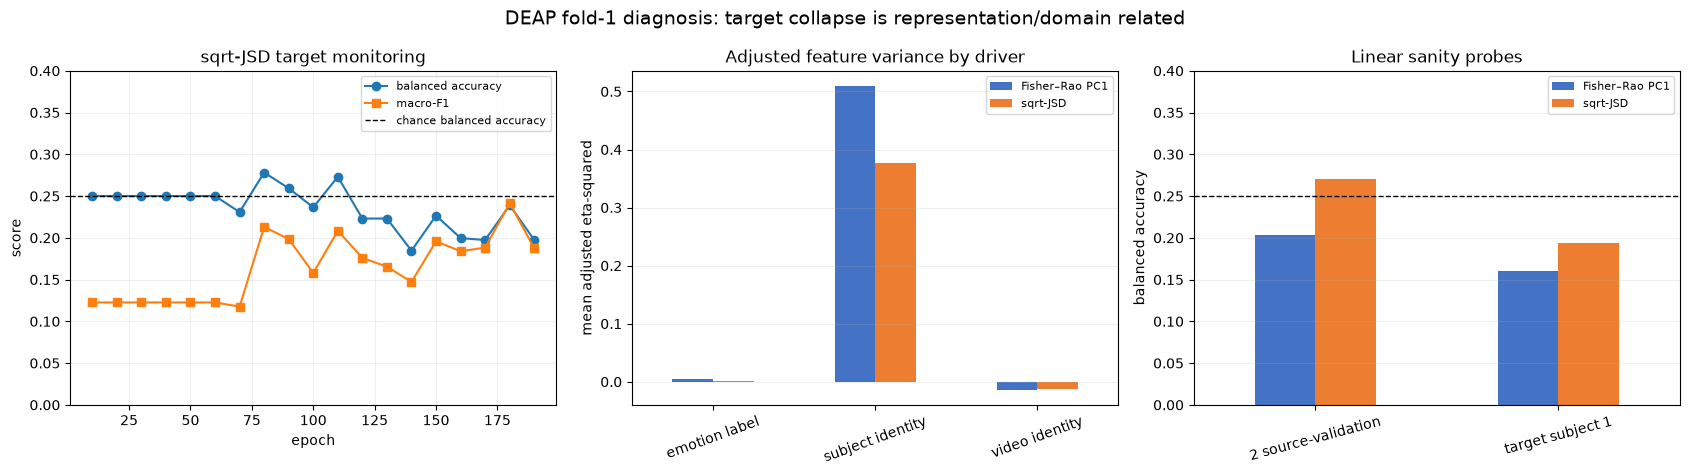

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

axes[0].plot(curve['epoch'], curve['balanced_accuracy'], marker='o', label='balanced accuracy')
axes[0].plot(curve['epoch'], curve['macro_f1'], marker='s', label='macro-F1')
axes[0].axhline(0.25, color='black', linestyle='--', linewidth=1, label='chance balanced accuracy')
axes[0].set(title='sqrt-JSD target monitoring', xlabel='epoch', ylabel='score', ylim=(0, 0.4))
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.2)

effect_pivot = effects.pivot(index='driver', columns='representation', values='mean_adjusted_eta_squared')
effect_pivot.plot(kind='bar', ax=axes[1], color=['#4472C4', '#ED7D31'])
axes[1].set(title='Adjusted feature variance by driver', xlabel='', ylabel='mean adjusted eta-squared')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', alpha=0.2)

probe_view = probes[(probes['classifier'] == 'logistic-unweighted') & (probes['fit_scope'] == '29 source-train')]
probe_pivot = probe_view.pivot(index='evaluation', columns='representation', values='balanced_accuracy')
probe_pivot.plot(kind='bar', ax=axes[2], color=['#4472C4', '#ED7D31'])
axes[2].axhline(0.25, color='black', linestyle='--', linewidth=1)
axes[2].set(title='Linear sanity probes', xlabel='', ylabel='balanced accuracy', ylim=(0, 0.4))
axes[2].tick_params(axis='x', rotation=15)
axes[2].legend(fontsize=8)
axes[2].grid(axis='y', alpha=0.2)

fig.suptitle('DEAP fold-1 diagnosis: target collapse is representation/domain related', fontsize=14)
fig.tight_layout()
plt.show()

## Interpretation and limits

- The 10-epoch target checks are diagnostic only and were not used to select a checkpoint. The run stopped after epoch 190, so there is no formal final sqrt-JSD result.
- Fisher–Rao has no neural training curve yet. Its linear probe and explained-variance ratios diagnose the cached representation, not the final neural model.
- The adjusted eta-squared comparison corrects for the number of groups, but remains a descriptive univariate variance decomposition rather than a causal attribution.
- Fold 1 contains only 40 target trials. A full method conclusion requires all 32 LOSO folds and multiple seeds.